<a href="https://colab.research.google.com/github/faizakhoeruzzahra/Tugas-Classification/blob/main/2304020187_TUGAS_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score # model evaluation

In [24]:
from google.colab import files
uploaded = files.upload()

Saving student-academic-stress-level.csv to student-academic-stress-level.csv


In [25]:
student_academic_stress_level_dataset = pd.read_csv("student-academic-stress-level.csv")
student_academic_stress_level_dataset

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5
...,...,...,...,...,...,...,...,...,...
135,17/08/2025 13:02:04,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,3,4
136,18/08/2025 14:36:00,undergraduate,4,2,disrupted,Analyze the situation and handle it with intel...,No,3,3
137,18/08/2025 17:13:52,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,2,4
138,18/08/2025 19:08:52,undergraduate,4,5,disrupted,"Social support (friends, family)",No,5,5


In [26]:
print(student_academic_stress_level_dataset.columns)

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')


In [27]:
student_academic_stress_level_dataset['Rate your academic stress index '].value_counts()

,count
Rate your academic stress index,
4,56
3,36
5,33
2,9
1,6


Berdasarkan output tersebut, nilai 4 memiliki frekuensi tertinggi sebanyak 56, diikuti nilai 3 sebanyak 36 dan nilai 5 sebanyak 33. Sementara itu, nilai 2 dan 1 memiliki frekuensi lebih sedikit, yaitu masing-masing 9 dan 6. Hal ini menunjukkan bahwa mayoritas responden memiliki tingkat stres akademik yang relatif tinggi.

In [28]:
student_academic_stress_level_dataset.describe()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index
count,140.000000,140.000000,140.000000,140.000000
mean,3.071429,3.178571,3.492857,3.721429
std,1.083844,1.276618,1.028349,1.032339
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


Berdasarkan output diatas, diperoleh ringkasan statistik dari kolom-kolom numerik dalam dataset, seperti jumlah data (count), nilai rata-rata (mean), standar deviasi (std), nilai minimum (min), kuartil (25%, 50%, 75%), dan nilai maksimum (max).

#Logistik Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [30]:
x = student_academic_stress_level_dataset.drop(columns= "Rate your academic stress index ")
y = student_academic_stress_level_dataset["Rate your academic stress index "]

In [ ]:
x

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4
...,...,...,...,...,...,...,...,...
135,17/08/2025 13:02:04,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,3
136,18/08/2025 14:36:00,undergraduate,4,2,disrupted,Analyze the situation and handle it with intel...,No,3
137,18/08/2025 17:13:52,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,2
138,18/08/2025 19:08:52,undergraduate,4,5,disrupted,"Social support (friends, family)",No,5


Berdasarkan hasil output, variabel x merupakan kumpulan berbagai faktor yang diduga memengaruhi tingkat stres akademik mahasiswa.

In [31]:
y

,Rate your academic stress index
0,5
1,3
2,4
3,3
4,5
...,...
135,4
136,3
137,4
138,5


Berdasarkan output, variabel y merupakan index yang menunjukkan tingkat stres mahasiswa.

In [40]:
from sklearn.model_selection import train_test_split
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 1)
x_train

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life
104,26/07/2025 09:47:04,high school,5,3,Noisy,Emotional breakdown (crying a lot),No,4
74,25/07/2025 11:00:10,undergraduate,5,5,Noisy,Emotional breakdown (crying a lot),No,3
12,24/07/2025 22:12:27,undergraduate,2,3,Noisy,Emotional breakdown (crying a lot),No,2
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2
48,24/07/2025 22:39:36,undergraduate,3,4,Noisy,Emotional breakdown (crying a lot),Yes,4
...,...,...,...,...,...,...,...,...
79,25/07/2025 13:18:47,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,prefer not to say,3
133,14/08/2025 06:10:01,post-graduate,4,3,disrupted,Emotional breakdown (crying a lot),Yes,2
137,18/08/2025 17:13:52,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,2
72,25/07/2025 10:37:39,undergraduate,1,1,Noisy,Analyze the situation and handle it with intel...,No,1


Berdasarkan output diatas, diperoleh faktor-faktor yang mempengaruhi tingkat stres mahasiswa.

In [41]:
x_test

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life
65,25/07/2025 00:10:10,undergraduate,4,5,disrupted,Emotional breakdown (crying a lot),No,2
58,24/07/2025 23:04:01,undergraduate,2,3,disrupted,Analyze the situation and handle it with intel...,No,3
42,24/07/2025 22:32:37,undergraduate,3,5,Peaceful,Analyze the situation and handle it with intel...,No,4
106,26/07/2025 10:01:33,high school,4,4,disrupted,Emotional breakdown (crying a lot),No,4
5,24/07/2025 22:08:13,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4
83,25/07/2025 16:31:45,post-graduate,1,5,Peaceful,Analyze the situation and handle it with intel...,No,5
29,24/07/2025 22:20:28,undergraduate,4,3,Peaceful,Analyze the situation and handle it with intel...,No,5
19,24/07/2025 22:17:46,undergraduate,3,4,Peaceful,"Social support (friends, family)",No,4
59,24/07/2025 23:15:48,undergraduate,3,1,Noisy,Analyze the situation and handle it with intel...,No,5
73,25/07/2025 10:43:24,undergraduate,3,3,disrupted,Analyze the situation and handle it with intel...,No,4


Berdasarkan output, diperoleh data yang digunakan untuk menguji ketepatan hasil prediksi tingkat stres akademik.

In [44]:
# High stress (4 atau 5) = 1, Low stress (1, 2, 3) = 0
y_train_binarized = y_train.apply(lambda val: 1 if val >= 4 else 0)

# Preprocess x_train
x_train_processed = x_train.copy()
if 'Timestamp' in x_train_processed.columns:
    x_train_processed = x_train_processed.drop(columns=['Timestamp'])

non_numeric_cols = x_train_processed.select_dtypes(include=['object']).columns

if not non_numeric_cols.empty:
    x_train_processed = pd.get_dummies(x_train_processed, columns=non_numeric_cols, drop_first=True, dtype=int)

for col in x_train_processed.select_dtypes(include='bool').columns:
    x_train_processed[col] = x_train_processed[col].astype(int)

# Add a constant term to the processed x_train for statsmodels
x_train_with_const = sm.add_constant(x_train_processed)

# Now fit the model with the binarized y_train and processed x_train
model = sm.Logit(y_train_binarized, x_train_with_const)
model_result = model.fit()

model_result.summary()

         Current function value: 0.478655
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  Logit Regression Results                                  
============================================================================================
Dep. Variable:     Rate your academic stress index    No. Observations:                   98
Model:                                        Logit   Df Residuals:                       86
Method:                                         MLE   Df Model:                           11
Date:                              Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2779
Time:                                      15:22:50   Log-Likelihood:                -46.908
converged:                                    False   LL-Null:                       -64.960
Covariance Type:                          nonrobust   LLR p-value:                 0.0001627
=========================================================================================================================================================
                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                    -4.4577      1.707     -2.611      0.009      -7.804      -1.111
Peer pressure                                                                             0.7002      0.296      2.364      0.018       0.120       1.281
Academic pressure from your home                                                          0.6392      0.251      2.547      0.011       0.147       1.131
What would you rate the academic  competition in your student life                        0.3280      0.297      1.103      0.270      -0.255       0.911
Your Academic Stage_post-graduate                                                        -1.4969      1.147     -1.305      0.192      -3.745       0.751
Your Academic Stage_undergraduate                                                        -1.1890      0.763     -1.559      0.119      -2.684       0.306
Study Environment_Peaceful                                                                0.6421      0.726      0.885      0.376      -0.780       2.065
Study Environment_disrupted                                                               0.7329      0.867      0.845      0.398      -0.967       2.433
What coping strategy you use as a student?_Emotional breakdown (crying a lot)             0.2059      0.792      0.260      0.795      -1.347       1.759
What coping strategy you use as a student?_Social support (friends, family)               1.3217      0.772      1.711      0.087      -0.192       2.835
Do you have any bad habits like smoking, drinking on a daily basis?_Yes                  27.3435   4.84e+05   5.65e-05      1.000   -9.48e+05    9.48e+05
Do you have any bad habits like smoking, drinking on a daily basis?_prefer not to say    -0.0305      1.236     -0.025      0.980      -2.453       2.392
=========================================================================================================================================================
"""

In [50]:
y_test_binarized = y_test.apply(lambda val: 1 if val >= 4 else 0)
x_test_processed = x_test.copy()

# Drop 'Timestamp' column if it exists
if 'Timestamp' in x_test_processed.columns:
    x_test_processed = x_test_processed.drop(columns=['Timestamp'])
non_numeric_cols_test = x_test_processed.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
if not non_numeric_cols_test.empty:
    x_test_processed = pd.get_dummies(x_test_processed, columns=non_numeric_cols_test, drop_first=True, dtype=int)

for col in x_test_processed.select_dtypes(include='bool').columns:
    x_test_processed[col] = x_test_processed[col].astype(int)

trained_feature_cols = [col for col in model_result.params.index if col != 'const']
x_test_aligned = x_test_processed.reindex(columns=trained_feature_cols, fill_value=0)
x_tes_with_const = sm.add_constant(x_test_aligned, has_constant='add')

pred = model_result.predict(x_tes_with_const)
import numpy as np # Import numpy
pred = np.where(pred <= 0.5, 0, 1)
pred

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1])

Berdasarkan output, hasil prediksi menunjukkan nilai 0 dan 1, yang berarti data dikelompokkan ke dalam dua kategori. Nilai 1 menunjukkan tingkat stres akademik yang lebih tinggi, sedangkan 0 menunjukkan tingkat stres yang lebih rendah. Terlihat bahwa sebagian besar data diprediksi berada pada kategori 1, sehingga dapat disimpulkan bahwa tingkat stres akademik cenderung tinggi pada data uji.

In [53]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test_binarized, pred) * 100

64.28571428571429

Berdasarkan output, diperoleh nilai akurasi sebesar 64,29%.

In [57]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(solver='liblinear', random_state=1)

# Fit the model using the processed x_train and binarized y_train
logistic_model.fit(x_train_processed, y_train_binarized)

# Make predictions on the test set using the processed data and binarized y_test
logistic_pred = logistic_model.predict(x_test_processed)

# Evaluate the model
accuracy = accuracy_score(y_test_binarized, logistic_pred) * 100
print(f"Accuracy of sklearn Logistic Regression model: {accuracy:.2f}%")

Accuracy of sklearn Logistic Regression model: 61.90%


Berdasarkan output, model Logistic Regression menghasilkan akurasi sebesar 61,90%.

In [58]:
pred = logistic_model.predict(x_test_processed)
pred

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Berdasarkan output diatas, nilai 1 lebih dominan dibandingkan 0, sehingga dapat disimpulkan bahwa sebagian besar mahasiswa diprediksi memiliki tingkat stres akademik yang lebih tinggi.

In [59]:
x_test1 = x_test.copy()
x_test1['Default_pred'] = pred
x_test1['Default'] = y_test
x_test1

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Default_pred,Default
65,25/07/2025 00:10:10,undergraduate,4,5,disrupted,Emotional breakdown (crying a lot),No,2,1,5
58,24/07/2025 23:04:01,undergraduate,2,3,disrupted,Analyze the situation and handle it with intel...,No,3,0,5
42,24/07/2025 22:32:37,undergraduate,3,5,Peaceful,Analyze the situation and handle it with intel...,No,4,1,5
106,26/07/2025 10:01:33,high school,4,4,disrupted,Emotional breakdown (crying a lot),No,4,1,5
5,24/07/2025 22:08:13,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,1,4
83,25/07/2025 16:31:45,post-graduate,1,5,Peaceful,Analyze the situation and handle it with intel...,No,5,1,3
29,24/07/2025 22:20:28,undergraduate,4,3,Peaceful,Analyze the situation and handle it with intel...,No,5,1,4
19,24/07/2025 22:17:46,undergraduate,3,4,Peaceful,"Social support (friends, family)",No,4,1,3
59,24/07/2025 23:15:48,undergraduate,3,1,Noisy,Analyze the situation and handle it with intel...,No,5,0,4
73,25/07/2025 10:43:24,undergraduate,3,3,disrupted,Analyze the situation and handle it with intel...,No,4,1,4


Dengan adanya kedua kolom ini, dapat dilakukan perbandingan antara hasil prediksi dan data asli untuk melihat kesesuaian atau ketepatan prediksi.

In [93]:
accuracy_score(y_test_binarized, pred) * 100

61.904761904761905

Berdasarkan output, diperoleh nilai akurasi sebesar 61.90%, yang menunjukkan bahwa tingkat ketepatan hasil prediksi terhadap data sebenarnya berada di kisaran 61.90%.

# KNN

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors= 7)
knn_model.fit(x_train_processed, y_train)

KNeighborsClassifier(n_neighbors=7)

In [64]:
knn_model = KNeighborsClassifier(n_neighbors= 7)
knn_model.fit(x_train_processed, y_train_binarized)
y_pred = knn_model.predict(x_test_processed)
accuracy_score(y_test_binarized, y_pred) * 100

54.761904761904766

Berdasarkan output, diperoleh akurasi sebesar 54,76% yang menunjukkan tingkat ketepatan prediksi masih rendah.

In [65]:
y_pred

array([1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1])

Berdasarkan output diatas, diperoleh hasil 1 lebih dominan dibandingkan 0, sehingga dapat disimpulkan bahwa mahasiswa  memiliki tingkat stres akademik yang tinggi.

In [70]:
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors= neighbor_num)
    knn_model.fit(x_train_processed, y_train_binarized)

    train_pred = knn_model.predict(x_train_processed)
    test_pred = knn_model.predict(x_test_processed)
    train_acc_score = accuracy_score(y_train_binarized, train_pred) * 100
    test_acc_score = accuracy_score(y_test_binarized, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)
    print("Neighbors_num: {0} --> Accuracy on Test Set: {1} %".format(neighbor_num, np.round(test_acc_score, 2)))

Neighbors_num: 1 --> Accuracy on Test Set: 57.14 %
Neighbors_num: 3 --> Accuracy on Test Set: 61.9 %
Neighbors_num: 5 --> Accuracy on Test Set: 54.76 %
Neighbors_num: 7 --> Accuracy on Test Set: 54.76 %
Neighbors_num: 9 --> Accuracy on Test Set: 57.14 %
Neighbors_num: 11 --> Accuracy on Test Set: 61.9 %
Neighbors_num: 13 --> Accuracy on Test Set: 61.9 %
Neighbors_num: 15 --> Accuracy on Test Set: 64.29 %
Neighbors_num: 17 --> Accuracy on Test Set: 59.52 %
Neighbors_num: 19 --> Accuracy on Test Set: 64.29 %
Neighbors_num: 21 --> Accuracy on Test Set: 64.29 %


Berdasarkan output, akurasi terbaik sebesar 64,29% diperoleh pada num 15, 19, dan 21, sehingga nilai tersebut merupakan yang paling optimal.

In [71]:
performance_df = pd.DataFrame({
    'Neighbors_num' : neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})

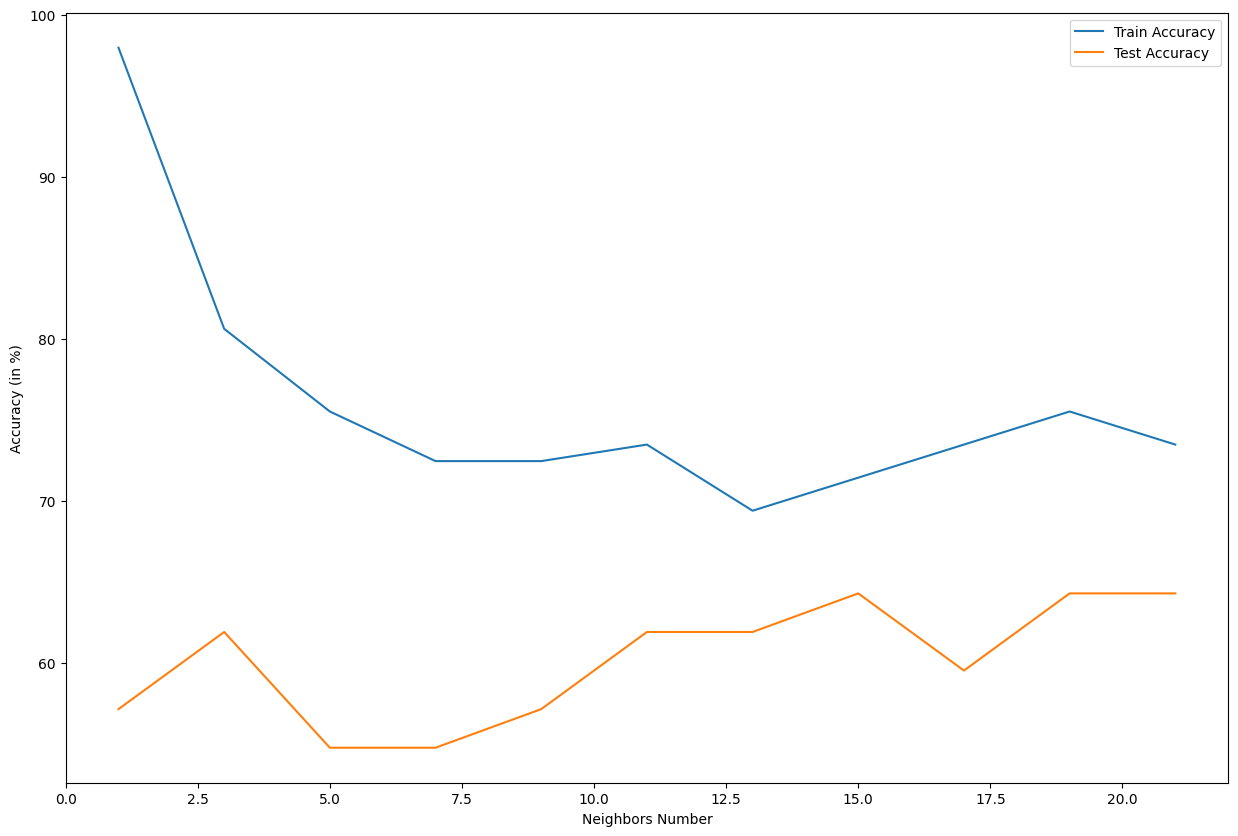

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(
    performance_df['Neighbors_num'] ,performance_df['Train Accuracy'],
    performance_df['Neighbors_num'] ,performance_df['Test Accuracy']
)
plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (in %)")
plt.legend(['Train Accuracy', 'Test Accuracy'])

Berdasarkan grafik, akurasi terbaik pada data uji diperoleh saat jumlah num lebih besar (sekitar 15, 19, dan 21), sehingga nilai tersebut lebih optimal.

In [76]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test_binarized, y_pred))
print(classification_report(y_test_binarized, y_pred, zero_division=0))

[[ 6  8]
 [11 17]]
              precision    recall  f1-score   support

           0       0.35      0.43      0.39        14
           1       0.68      0.61      0.64        28

    accuracy                           0.55        42
   macro avg       0.52      0.52      0.51        42
weighted avg       0.57      0.55      0.56        42



Berdasarkan hasil evaluasi, akurasi keseluruhan untuk model KNN setelah binarisasi adalah sekitar 55%.

# Decision Tree

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing

In [85]:
classifier = DecisionTreeClassifier()
classifier.fit(x_train_processed, y_train_binarized)

DecisionTreeClassifier()

In [86]:
y_pred = classifier.predict(x_test_processed)
import numpy as np
print("Unique values in y_train_binarized:", y_train_binarized.unique())
print("Classes learned by classifier:", classifier.classes_)
print("Unique values in y_pred (after fitting with binarized data):", np.unique(y_pred))

Unique values in y_train_binarized: [1 0]
Classes learned by classifier: [0 1]
Unique values in y_pred (after fitting with binarized data): [0 1]


In [87]:
from sklearn.metrics import classification_report, confusion_matrix

# y_pred is already calculated in the previous cell (JgRlPphDpwhu)
print(confusion_matrix(y_test_binarized, y_pred))
print(classification_report(y_test_binarized, y_pred, zero_division=0))

[[ 7  7]
 [ 8 20]]
              precision    recall  f1-score   support

           0       0.47      0.50      0.48        14
           1       0.74      0.71      0.73        28

    accuracy                           0.64        42
   macro avg       0.60      0.61      0.61        42
weighted avg       0.65      0.64      0.65        42



Berdasarkan hasil evaluasi, akurasi sebesar 64% menunjukkan hasil prediksi sudah cukup baik dengan kesalahan yang lebih sedikit.

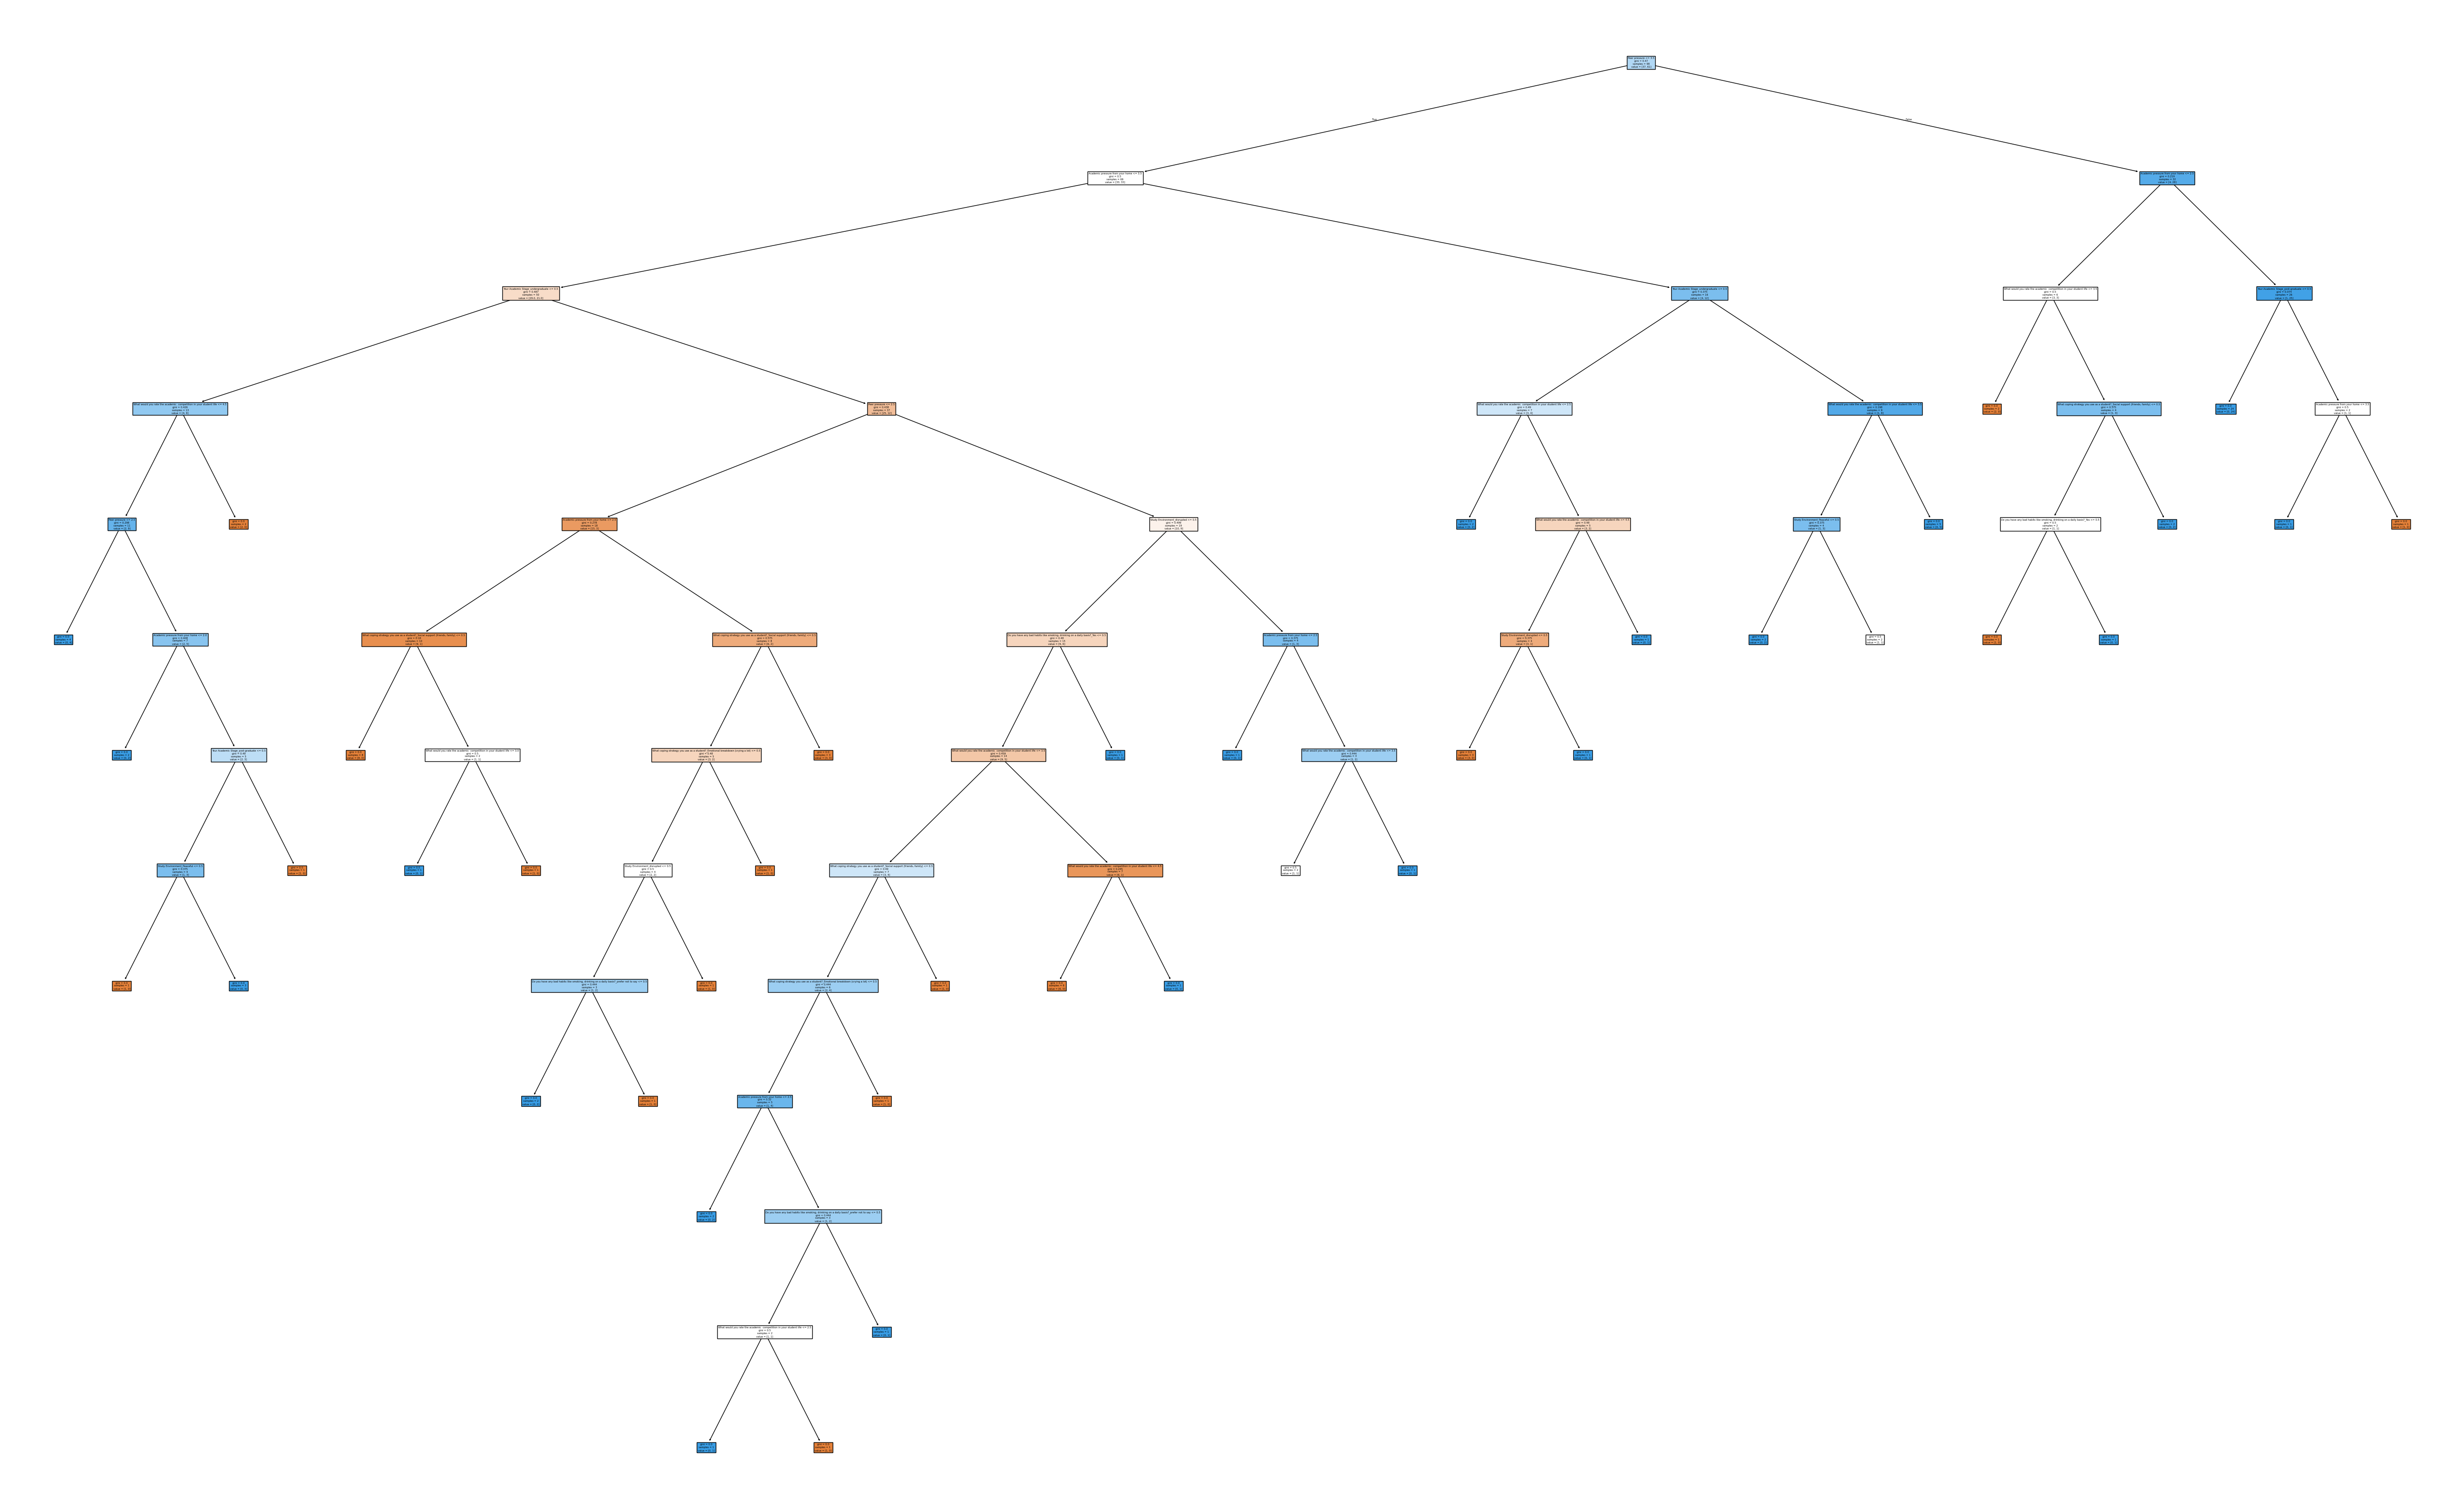

In [88]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize = (65,40))
plot_tree(classifier, feature_names=x_train_processed.columns, filled=True)
plt.show()

Model tersebut mampu mengklasifikasikan data dengan baik, tetapi kompleksitasnya tinggi sehingga perlu dikontrol agar lebih general saat digunakan pada data baru.

In [109]:
# import Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier

rfc = RandomForestClassifier(random_state=0)

# fit the model

rfc.fit(x_train_processed, y_train_binarized)

RandomForestClassifier(random_state=0)

In [110]:
# Predict the Test set results

y_pred = rfc.predict(x_test_processed)
y_pred

array([1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1])

Hasil menunjukkan prediksi terhadap data uji. Angka 0 dan 1 menunjukkan tingkat stres akademik yang rendah atau tinggi, sesuai dengan binarisasi.

In [111]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test_binarized, y_pred)))

Model accuracy score with 10 decision-trees : 0.6190


Berdasarkan output menunjukkan tingkat ketepatan dengan akurasi 61,90%.

In [112]:
# define the parameter list
max_depth_tree_list = np.arange(1, 20, 2)
tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['log_loss', 'gini', 'entropy'],
}

In [113]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid_search = GridSearchCV(
    estimator= DecisionTreeClassifier(),
    param_grid= tree_params_list,
    cv= StratifiedKFold(n_splits= 3),
    scoring= 'precision'
)
grid_search.fit(x_train_processed, y_train_binarized)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['log_loss', 'gini', 'entropy'],
                         'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='precision')

In [114]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=np.int64(7))

In [115]:
best_model = grid_search.best_estimator_

In [116]:
y_best = best_model.predict(x_test_processed)
y_best

array([1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1])

Berdasarkan output, angka 1 lebih dominan dari angka 0 yang merupakan hasil klasifikasi dari uji.

In [117]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test_binarized, y_best))
print(classification_report(y_test_binarized, y_best, zero_division=0))

[[ 6  8]
 [10 18]]
              precision    recall  f1-score   support

           0       0.38      0.43      0.40        14
           1       0.69      0.64      0.67        28

    accuracy                           0.57        42
   macro avg       0.53      0.54      0.53        42
weighted avg       0.59      0.57      0.58        42



Berdasarkan output, diperoleh nilai akurasi 57%.

# Support Vector Machine

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn import datasets
from sklearn.metrics import confusion_matrix

In [119]:
from sklearn.metrics import roc_auc_score
from sklearn import svm
cv=StratifiedKFold(n_splits=2,random_state=None)
ss=svm.SVC(class_weight=None,random_state=2)
# The original 'x' and 'y' contain non-numeric data.
# We should use the preprocessed data for fitting the model.
# model=ss.fit(x,y) # This line caused the ValueError

parameter={
    'kernel':('linear','poly','rbf'),
    'C':[0.0001,0.001,0.01,0.1,1,10,100,1000,10000],
    'gamma':[0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
}

# Initialize GridSearchCV with an unfitted estimator and fit it with processed data
grid=GridSearchCV(ss,parameter,cv=cv,n_jobs=1,scoring='accuracy')
grid.fit(x_train_processed, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
             estimator=SVC(random_state=2), n_jobs=1,
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                               10000],
                         'gamma': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                   10000],
                         'kernel': ('linear', 'poly', 'rbf')},
             scoring='accuracy')

In [120]:
from sklearn import svm
svm_model = svm.SVC(class_weight=None,C=1,gamma=0.1,kernel='linear',random_state=100)
n=5
from sklearn.model_selection import StratifiedKFold
kf=StratifiedKFold(n_splits=n,random_state=None)

In [121]:
svm_model.fit(x_train_processed, y_train_binarized)
y_pred_svm = svm_model.predict(x_test_processed)
y_pred_svm

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1])

In [123]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test_binarized, y_pred_svm))
print(classification_report(y_test_binarized, y_pred_svm, zero_division=0))

[[ 4 10]
 [ 5 23]]
              precision    recall  f1-score   support

           0       0.44      0.29      0.35        14
           1       0.70      0.82      0.75        28

    accuracy                           0.64        42
   macro avg       0.57      0.55      0.55        42
weighted avg       0.61      0.64      0.62        42



Berdasarkan output yang diperbarui, diperoleh bahwa model SVM sudah berhasil dioptimasi dengan akurasi 64%.